In [42]:
import pandas as pd
import numpy as np
from datetime import datetime, timezone
import json
from tqdm import tqdm




In [43]:
def flatten_posts_dict(posts_by_tag):
    flat_posts = {}
    for tag, posts in posts_by_tag.items():
        for uri, post in posts.items():
            post = dict(post)          
            post["hashtag"] = tag      
            flat_posts[uri] = post
    return flat_posts


def add_reposters_to_posts(posts_dict, users):
    for post in posts_dict.values():
        post["reposted_by"] = []

    for did, user in users.items():
        for uri in user.get("reposted_posts", []):
            if uri in posts_dict:
                posts_dict[uri]["reposted_by"].append(did)

    for post in posts_dict.values():
        post["repost_user_unobservable"] = (
            post.get("repostCount", 0) > 0 and not post["reposted_by"]
        )

In [44]:

with open("TEST.json", "r", encoding="utf-8") as f:
    raw_user_data = json.load(f)

with open("posts.json", "r", encoding="utf-8") as f:
    posts = json.load(f)

post_dict = flatten_posts_dict(posts)
add_reposters_to_posts(post_dict, raw_user_data)

In [48]:
import numpy as np
import pandas as pd
from datetime import datetime, timezone
from tqdm import tqdm


# =====================================================
# Time utilities (timezone-safe)
# =====================================================

def parse_dt(ts):
    if not ts:
        return None
    try:
        return datetime.fromisoformat(
            ts.replace("Z", "+00:00")
        ).astimezone(timezone.utc)
    except Exception:
        return None


# =====================================================
# Safe History Filtering
# =====================================================

def filter_history_before_post(history, post_time, exclude_post_id=None):

    if not history or not post_time:
        return []

    filtered = []

    for h in history:

        if exclude_post_id and h.get("post_id") == exclude_post_id:
            continue

        ts = (
            h.get("reposted_at")
            or h.get("created_at")
            or h.get("indexedAt")
        )

        t = parse_dt(ts)

        if not t:
            continue

        if t >= post_time:
            continue

        filtered.append(h)

    return filtered


# =====================================================
# History-based features
# =====================================================

def history_stats(history, post_time, exclude_post_id=None):

    hist = filter_history_before_post(
        history, post_time, exclude_post_id
    )

    if not hist:
        return 0.0, None, None  # 3 values only

    reposts = 0
    engagements = []
    times = []

    for h in hist:

        if h.get("activity_type") == "repost":
            reposts += 1

        ts = (
            h.get("created_at")
            or h.get("reposted_at")
            or h.get("indexedAt")
        )

        t = parse_dt(ts)
        if t:
            times.append(t)

        for k in ("like_count", "repost_count", "reply_count", "quote_count"):
            if h.get(k) is not None:
                engagements.append(h[k])

    times.sort()
    gaps = [
        (times[i] - times[i - 1]).days
        for i in range(1, len(times))
    ]

    return (
        reposts / len(hist) if hist else 0.0,
        np.mean(gaps) if gaps else None,
        np.mean(engagements) if engagements else None,
    )



def mention_stats(history, handle, post_time, exclude_post_id=None):

    hist = filter_history_before_post(
        history, post_time, exclude_post_id
    )

    if not hist or not handle:
        return 0, 0.0

    total = len(hist)
    count = sum(
        handle in (h.get("text") or "")
        for h in hist
    )

    return count, count / total


def reposts_from_author_before(history, author_did, post_time, exclude_post_id=None):

    hist = filter_history_before_post(
        history, post_time, exclude_post_id
    )

    return sum(
        1
        for h in hist
        if h.get("activity_type") == "repost"
        and h.get("post_author_did") == author_did
    )


# =====================================================
# User feature extraction
# =====================================================

def user_profile_features(user, max_posts, prefix):

    age = user["stats"]["account_age_days"] or 1
    posts = user["stats"]["posts"] or 0

    return {
        f"U-P_{prefix}_AccountAge": age,
        f"U-P_{prefix}_FollowerNum": user["stats"]["followers"],
        f"U-P_{prefix}_FolloweeNum": user["stats"]["follows"],
        f"U-P_{prefix}_TweetNum": posts,
        f"U-P_{prefix}_SpreadActivity": posts / max_posts,
        f"U-P_{prefix}_FollowerNumDay": user["stats"]["followers"] / age,
        f"U-P_{prefix}_FolloweeNumDay": user["stats"]["follows"] / age,
        f"U-P_{prefix}_TweetNumDay": posts / age,
        f"U-P_{prefix}_ProfileUrl":
            int("http" in (user["profile"]["description"] or "")),
    }


def user_history_features(user, post_time, exclude_post_id, prefix):

    repost_pct, avg_gap, avg_eng = history_stats(
        user["history"],
        post_time,
        exclude_post_id
    )

    return {
        f"U-HA_{prefix}_RetweetPercent": repost_pct,
        f"U-HA_{prefix}_AverageInterval": avg_gap,
        f"U-HA_{prefix}_RetweetedRate": avg_eng,
    }



# =====================================================
# Unified Row Builder
# =====================================================

def build_row(A_id, S_id, P_id, post, users, max_posts, label):

    A = users[A_id]
    S = users[S_id]

    P_time = parse_dt(post.get("indexedAt"))
    if not P_time:
        return None

    hashtag = post.get("hashtag")

    # Profile features
    A_profile = user_profile_features(A, max_posts, "R")
    S_profile = user_profile_features(S, max_posts, "S")

    # History features
    A_hist = user_history_features(A, P_time, P_id, "R")
    S_hist = user_history_features(S, P_time, P_id, "S")

    # Mentions
    A_m_S, A_m_S_per = mention_stats(
        A["history"],
        S["profile"]["handle"],
        P_time,
        exclude_post_id=P_id,
    )

    S_m_A, S_m_A_per = mention_stats(
        S["history"],
        A["profile"]["handle"],
        P_time,
        exclude_post_id=P_id,
    )

    row = {
        "A_id": A_id,
        "S_id": S_id,
        "P_id": P_id,
        "hashtag": hashtag,
        "label": label,

        # Interaction features
        "U-P_R_FollowS": int(S_id in A.get("follows_authors", [])),
        "U-HA_RS_Mention": A_m_S,
        "U-HA_RS_MentionPer": A_m_S_per,
        "U-HA_SR_Mention": S_m_A,
        "U-HA_SR_MentionPer": S_m_A_per,
        "U-HA-RS_reposts":
            reposts_from_author_before(
                A["history"], S_id, P_time, exclude_post_id=P_id
            ),
        "U-P_SR_followersDiff":
            S["stats"]["followers"] - A["stats"]["followers"],
        "U-P_R_activeBeforeP":
            int(parse_dt(A["profile"].get("created_at")) < P_time)
            if A["profile"].get("created_at") else 0,
    }

    row.update(A_profile)
    row.update(S_profile)
    row.update(A_hist)
    row.update(S_hist)

    return row


# =====================================================
# FINAL DATASET BUILDER
# =====================================================

def build_repost_triples_df(
    users,
    posts_dict,
    neg_per_pos,
    seed=42,
):

    rng = np.random.default_rng(seed)
    all_users = set(users.keys())
    post_items = list(posts_dict.items())

    max_posts = max(
        u["stats"]["posts"] or 1
        for u in users.values()
    )

    rows = []

    for P_id, post in tqdm(post_items, desc="Building Dataset"):

        S_id = post.get("author", {}).get("did")
        if not S_id or S_id not in users:
            continue

        reposted_by = post.get("reposted_by", [])
        if not reposted_by:
            continue

        A_id = rng.choice(reposted_by)
        if A_id not in users:
            continue

        pos_row = build_row(
            A_id, S_id, P_id,
            post, users, max_posts,
            label=1
        )

        if pos_row:
            rows.append(pos_row)

        candidate_users = all_users - {S_id}
        neg_pool = list(candidate_users - set(reposted_by))

        if neg_pool:
            negs = rng.choice(
                neg_pool,
                size=min(neg_per_pos, len(neg_pool)),
                replace=False,
            )

            for neg_A in negs:
                neg_row = build_row(
                    neg_A, S_id, P_id,
                    post, users, max_posts,
                    label=0
                )
                if neg_row:
                    rows.append(neg_row)

    return pd.DataFrame(rows)


In [ ]:
# make sure to not include the post we are looking at inside history (if there)

In [49]:
df = build_repost_triples_df(
    raw_user_data,
    post_dict,
    neg_per_pos=1
)
print(df.shape)


Building Dataset: 100%|██████████| 169904/169904 [08:33<00:00, 330.70it/s] 


(71156, 37)


In [50]:
def remove_pair_duplicates(df):
    # Drop duplicate S_id, A_id pairs
    df_clean = df.drop_duplicates(subset=["S_id", "A_id"])
    return df_clean

remove_pair_duplicates(df).to_csv("1_to_1.csv", index=False)

In [27]:
def count_pairs(df):
    return df[["A_id", "S_id"]].drop_duplicates().shape[0]

def count_S_and_A(df):
    print(f"Unique #R: {df[['A_id']].drop_duplicates().shape[0]}")
    print(f"Unique #S: {df[['S_id']].drop_duplicates().shape[0]}")



print(f"Unique number of (S,R) pairs in dataframe: {count_pairs(df)}")
print(f" Total number of pairs: {df.shape[0]}")
count_S_and_A(df)


Unique number of (S,R) pairs in dataframe: 70050
 Total number of pairs: 71156
Unique #R: 37864
Unique #S: 9778


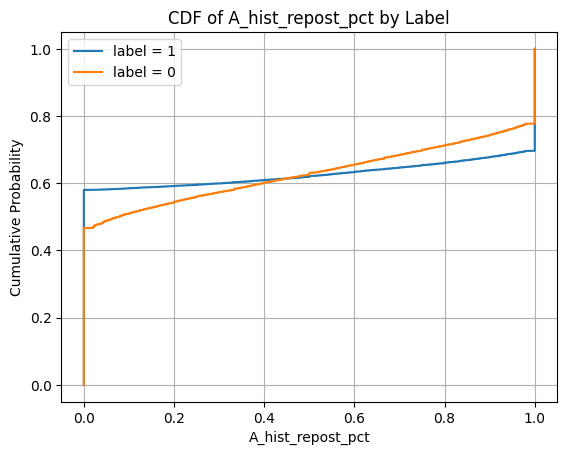

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cdf_U_HA_R_RetweetPercent(df):
    """
    Plots the cumulative distribution function (CDF)
    of U-HA_R_RetweetPercent for label=1 and label=0.
    """

    # Remove missing values
    df_clean = df.dropna(subset=["U-HA_R_RetweetPercent", "label"])

    # Split by label
    pos = df_clean[df_clean["label"] == 1]["U-HA_R_RetweetPercent"].values
    neg = df_clean[df_clean["label"] == 0]["U-HA_R_RetweetPercent"].values

    # Sort
    pos_sorted = np.sort(pos)
    neg_sorted = np.sort(neg)

    # Compute empirical CDF
    pos_cdf = np.arange(1, len(pos_sorted) + 1) / len(pos_sorted) if len(pos_sorted) > 0 else None
    neg_cdf = np.arange(1, len(neg_sorted) + 1) / len(neg_sorted) if len(neg_sorted) > 0 else None

    # Plot (single plot, no colors specified)
    plt.figure()

    if pos_cdf is not None:
        plt.plot(pos_sorted, pos_cdf)

    if neg_cdf is not None:
        plt.plot(neg_sorted, neg_cdf)

    plt.xlabel("U-HA_R_RetweetPercent")
    plt.ylabel("Cumulative Probability")
    plt.title("CDF of A_hist_repost_pct by Label")
    plt.legend(["label = 1", "label = 0"])
    plt.grid(True)
    plt.show()

plot_cdf_U_HA_R_RetweetPercent(df) # Note we have not made sure to excldue the "repost" in history (likey bias adding one to history for all with label=1)